In [1]:
from spikenet.dataset.spiking_mnist import SpikingMNISTDataLoader
from spikenet.image_to_spike_convertor import SpikePlotter
from spikenet.network import Network

spiking_mnist = SpikingMNISTDataLoader(frame_size=14)
splt = SpikePlotter()

shape:
  - x: torch.Size([1, 16, 14, 14])
  - y: torch.Size([])
  - batch_size: 128


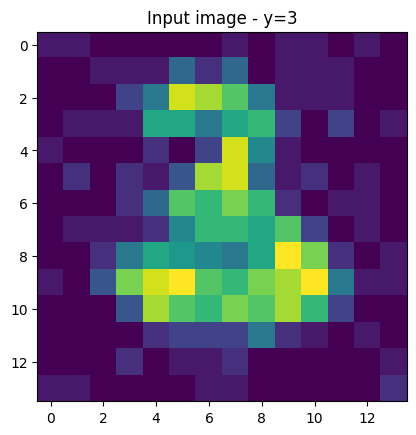

In [2]:
import matplotlib.pyplot as plt

test_data = spiking_mnist.sample()
spiking_mnist.describe()
data_x, data_y = test_data

img = data_x.reshape([spiking_mnist.time_scale, *spiking_mnist.frame_size])
img = img.sum(0)
plt.imshow(img)
plt.title(f"Input image - y={data_y}")
plt.show()

In [3]:
from spikenet.layers.spiking_base import TimeReduction
from spikenet.layers.spiking_conv2d import SpikingConv2D
from spikenet.layers.spiking_dense import SpikingDenseLayer
from spikenet.layers.spiking_pooling import SpikingPoolingLayer

net = (
    Network()
    .add_layer(SpikingConv2D, 16, in_features=1, in_size=(14, 14))
    .add_layer(SpikingPoolingLayer, in_size=(14, 14), out_size=(7, 7))
    .add_layer(SpikingConv2D, 32, in_features=16, in_size=(14, 14))
    .add_layer(SpikingPoolingLayer, in_size=(7, 7), out_size=(3, 3))
    .add_layer(SpikingDenseLayer, 600)
    .add_layer(SpikingDenseLayer, 10, time_reduction=TimeReduction.MemRecMax)
).build()

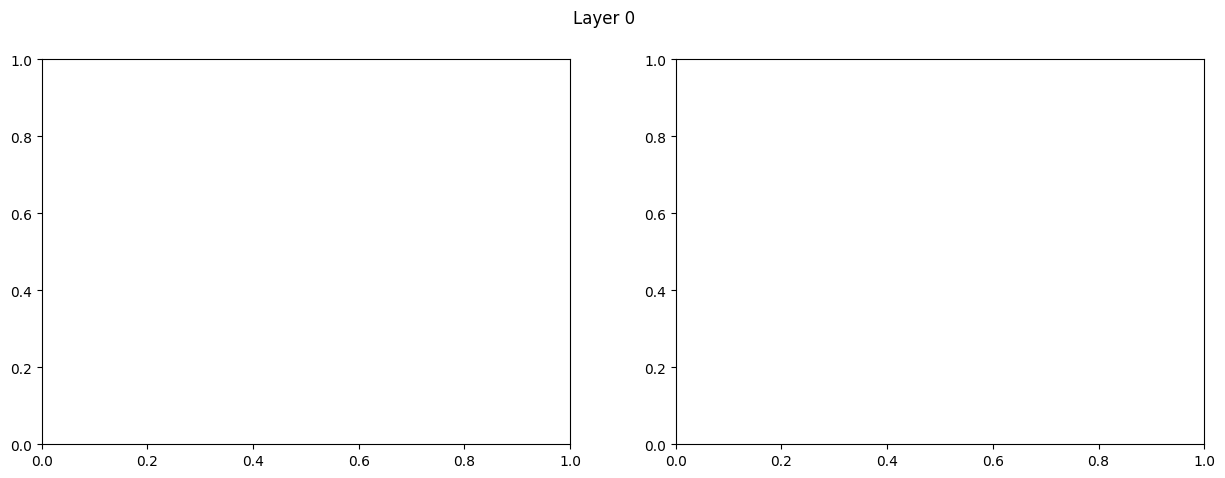

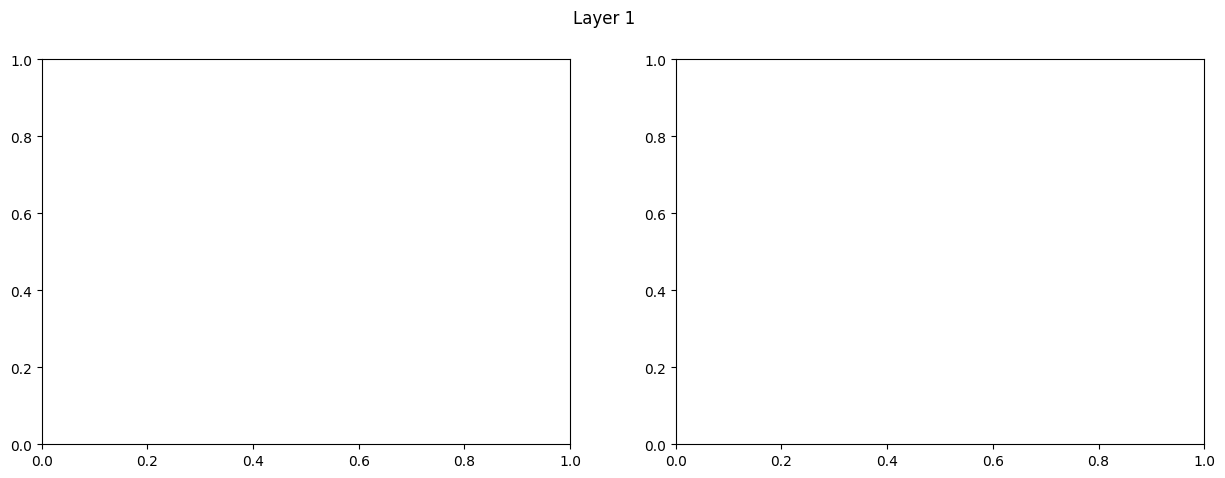

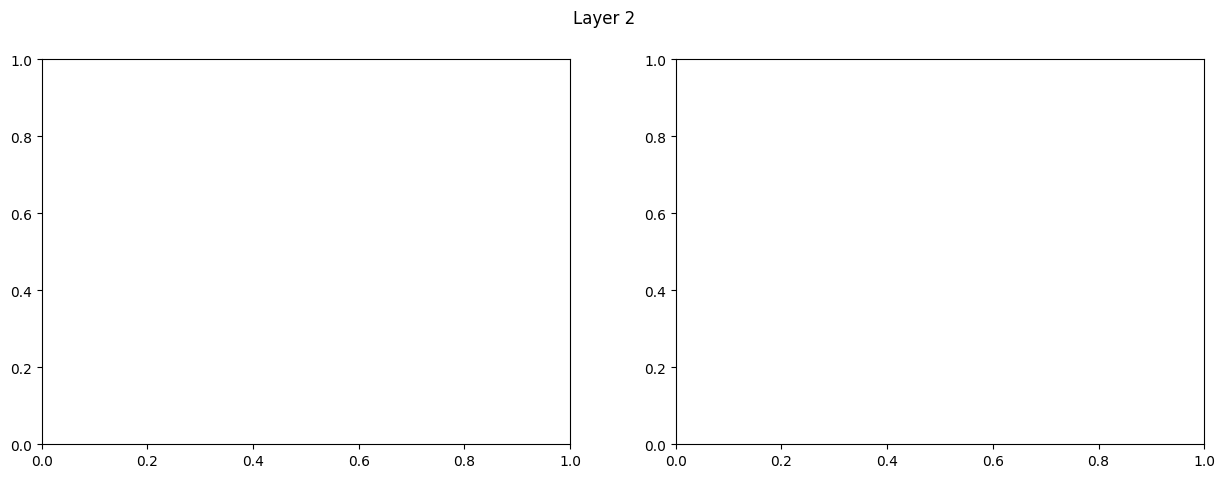

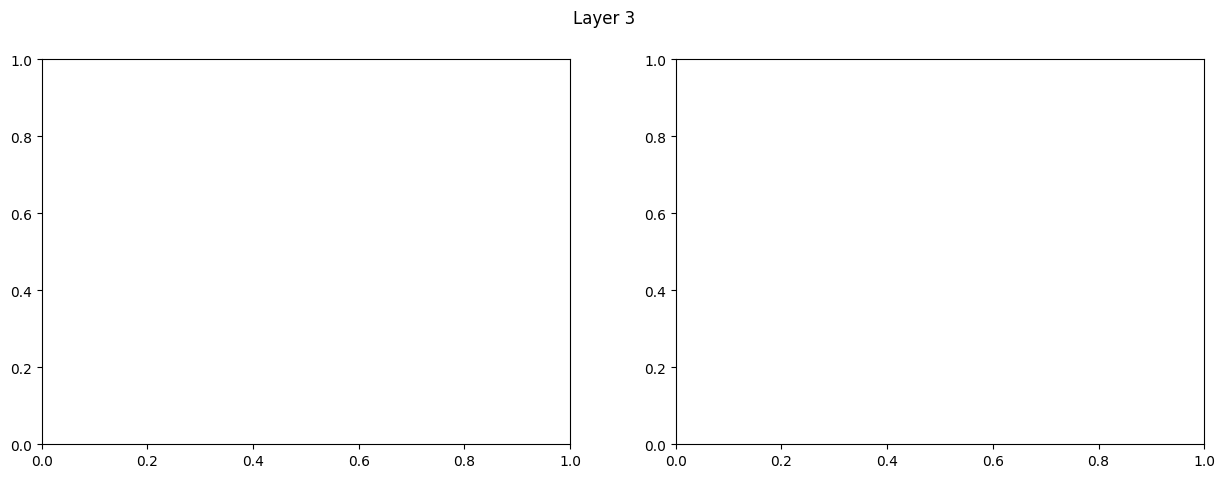

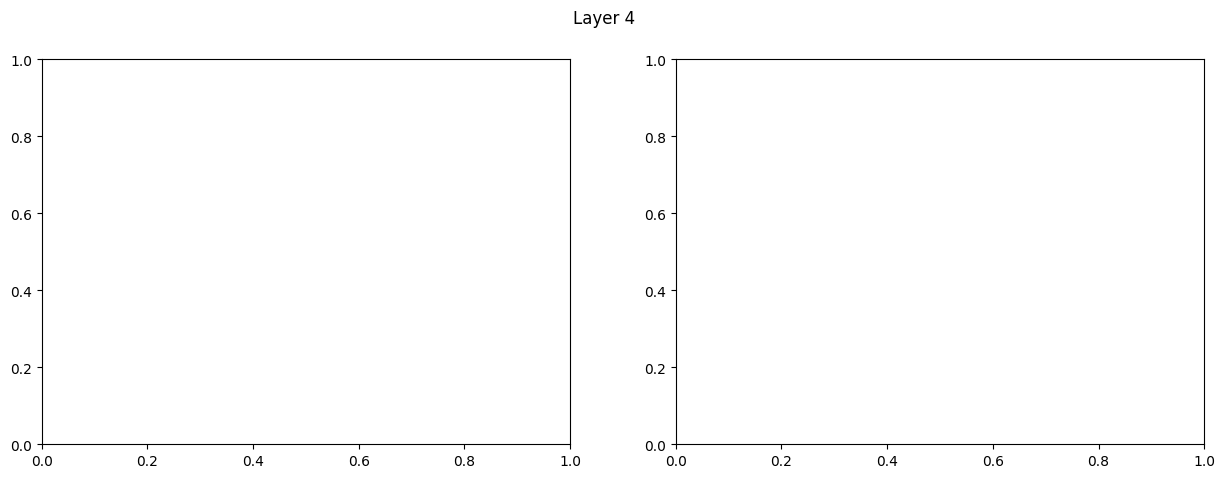

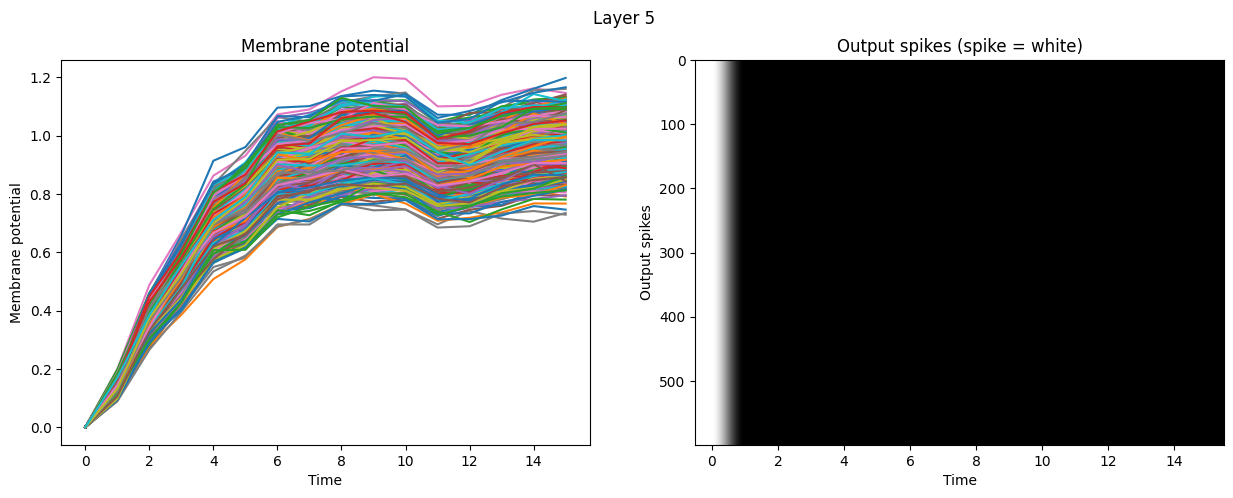

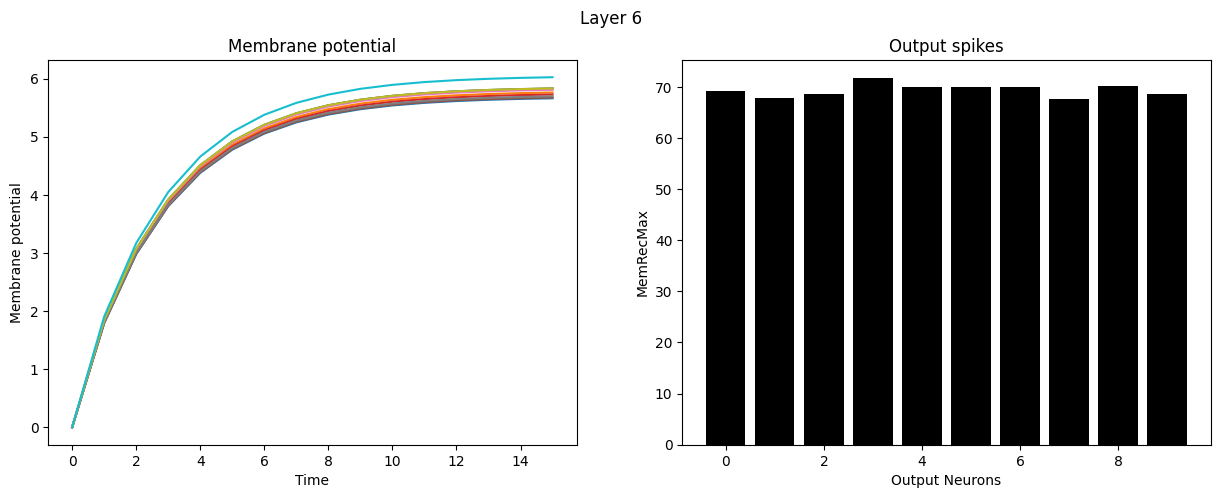

In [4]:
net.forward(data_x.reshape(1, *data_x.shape))
net.plot_activity()

===== Training Started ======
Epoch 1 | ............................................... | Loss: 2.2285
Epoch 2 | ............................................... | Loss: 2.2499
Epoch 3 | ............................................... | Loss: 2.0634
===== Training Finished =====


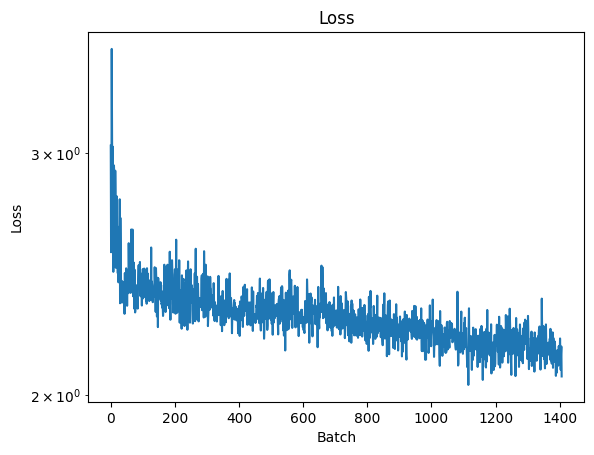

====== Testing Started ======
Accuracy: 1988/10000 = 19.88%
===== Testing Finished ======


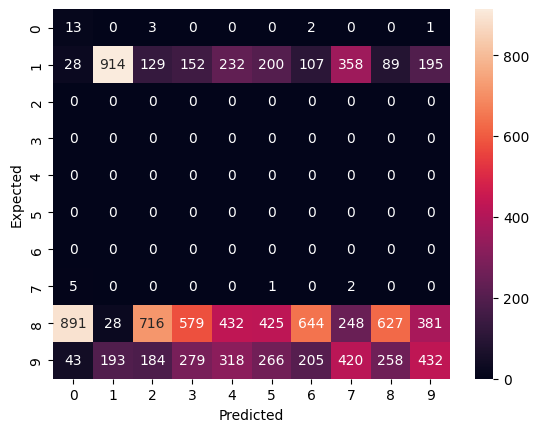

Network:
ModuleList(
  (0): SpikingConv2D()
  (1): SpikingPoolingLayer()
  (2): SpikingConv2D()
  (3): SpikingPoolingLayer()
  (4): Flatten()
  (5-6): 2 x SpikingDenseLayer()
)

In [5]:
net.fit(
    spiking_mnist,
    # epochs=3
)

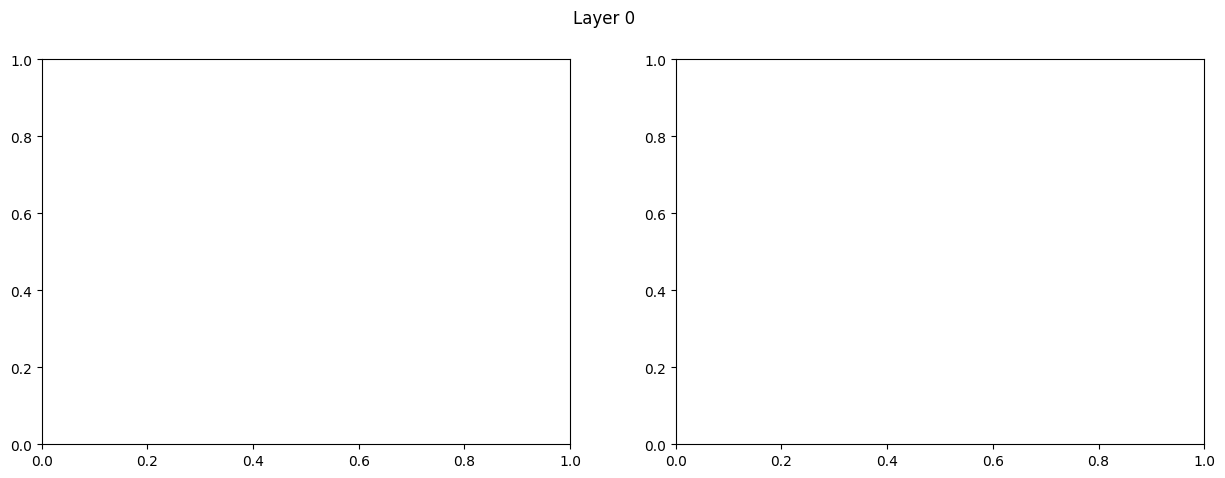

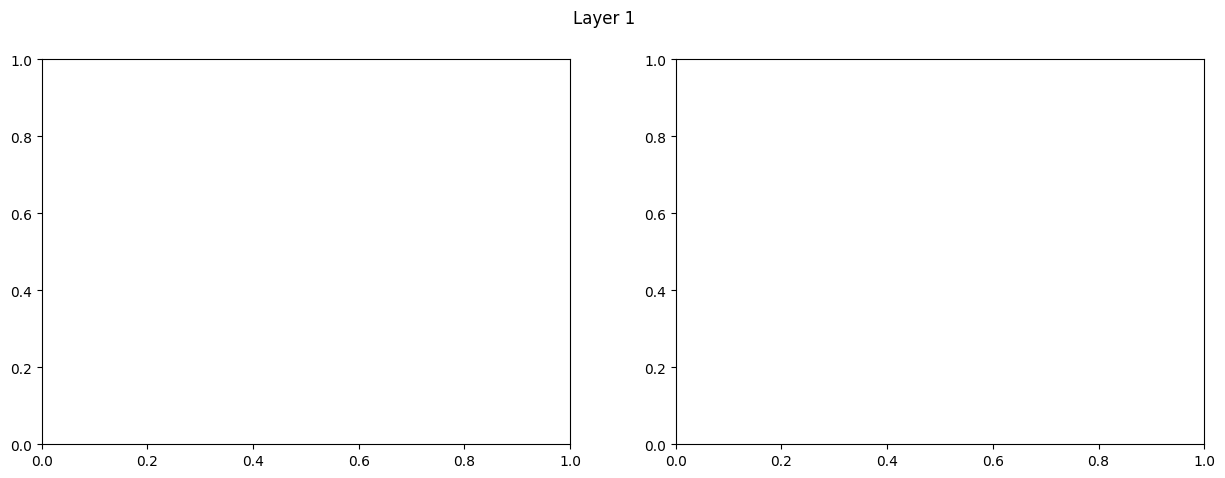

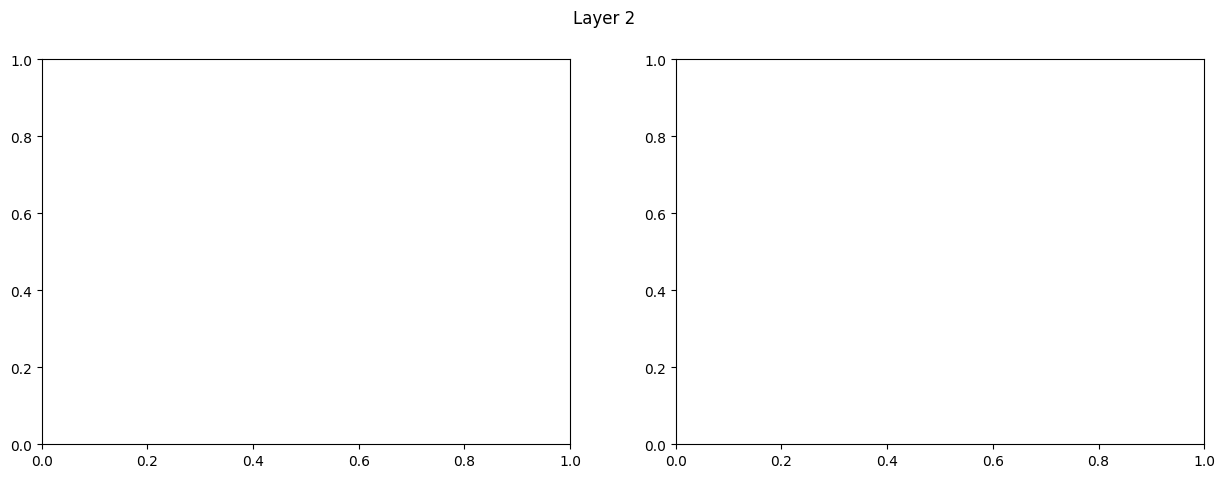

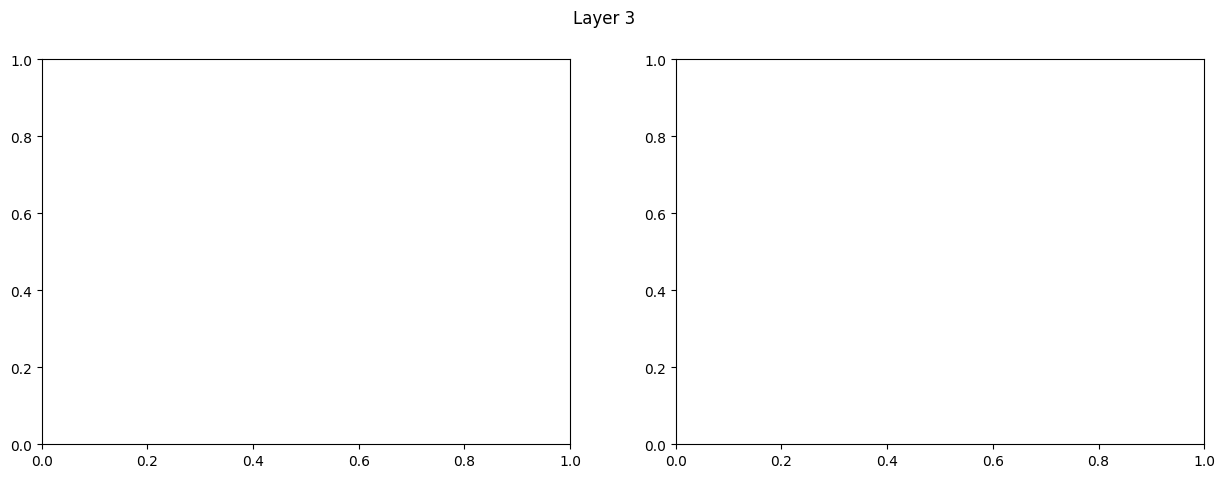

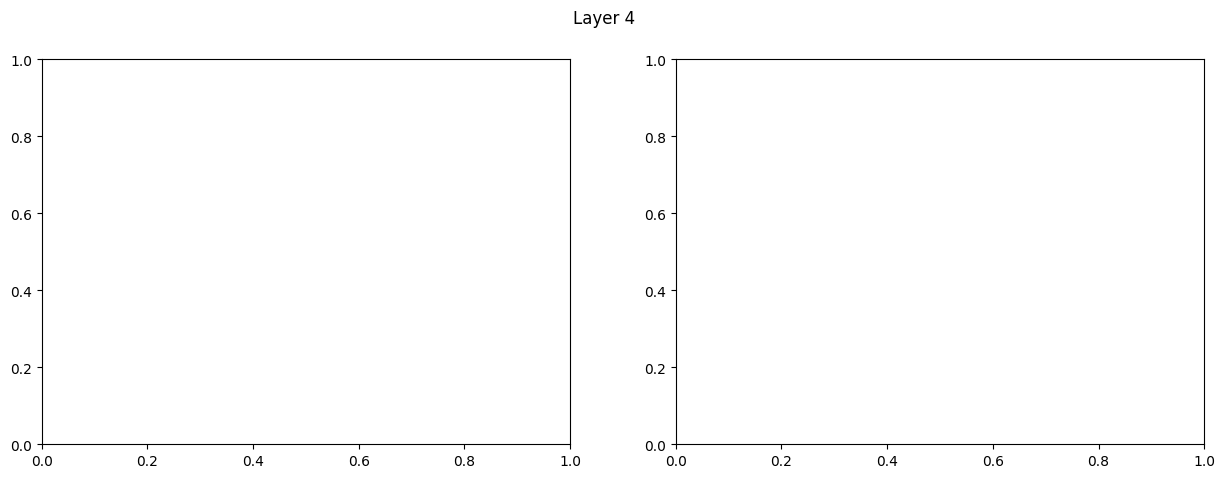

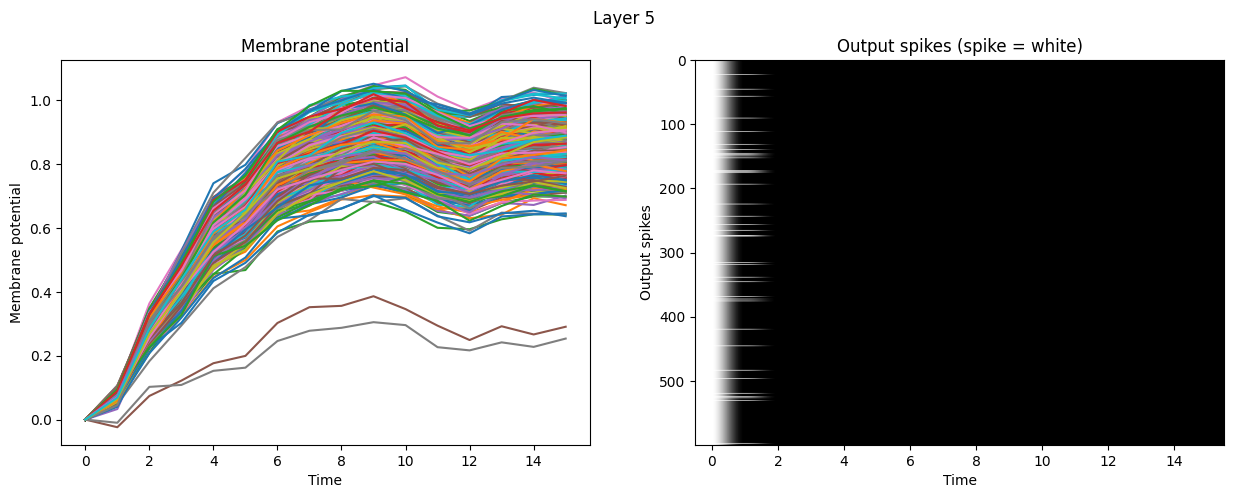

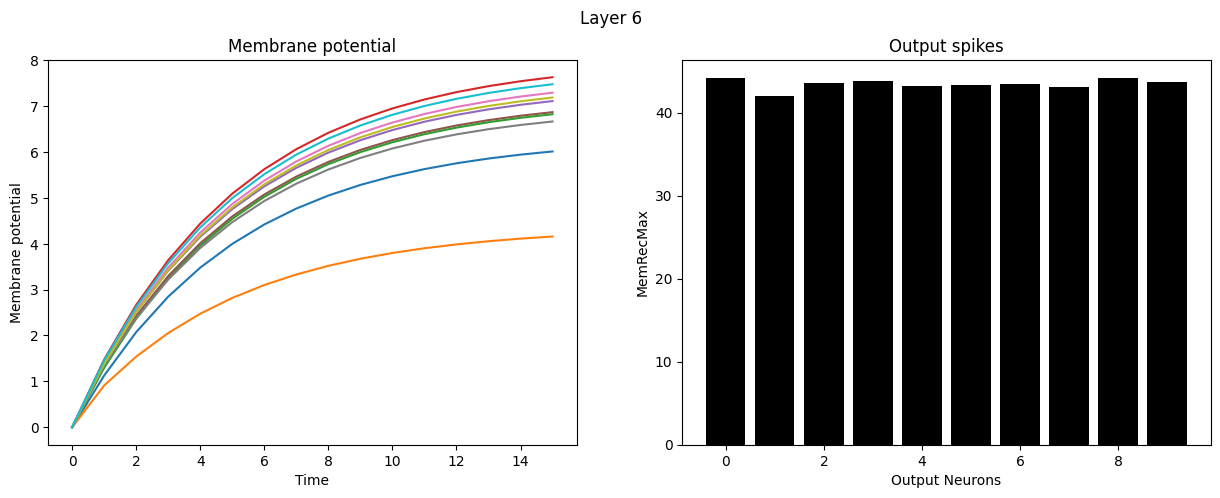

In [6]:
net.forward(data_x.reshape(1, *data_x.shape))
net.plot_activity()